## Import

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

### Load Data

In [22]:
df = pd.read_csv('data\\anomaly_train.csv')

X_train = df[['x1', 'x2']].values

X_val = pd.read_csv('data\\anomaly_val.csv')[['x1', 'x2']].values
y_val = pd.read_csv('data\\anomaly_val.csv')['y'].values


In [23]:
print ('The shape of X_train is:', X_train.shape)
print ('The shape of X_val is:', X_val.shape)
print ('The shape of y_val is: ', y_val.shape)

The shape of X_train is: (307, 2)
The shape of X_val is: (307, 2)
The shape of y_val is:  (307,)


### Plot Data

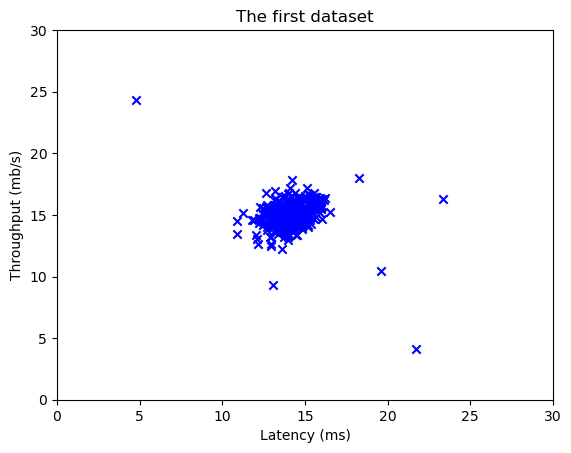

In [24]:
# Create a scatter plot of the data. To change the markers to blue "x",
# we used the 'marker' and 'c' parameters
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 

# Set the title
plt.title("The first dataset")
# Set the y-axis label
plt.ylabel('Throughput (mb/s)')
# Set the x-axis label
plt.xlabel('Latency (ms)')
# Set axis range
plt.axis([0, 30, 0, 30])
plt.show()

### Estimating parameters for a Gaussian distribution

Estimating the parameters, ($\mu_i$, $\sigma_i^2$), of the $i$-th
feature by using the following equations.<br> To estimate the mean:
$$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$

and for the variance:
$$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$


In [25]:
def estimate_gaussian(X): 
    """
    Calculates mean and variance of all features 
    in the dataset
    
    Args:
        X (ndarray): (m, n) Data matrix
    
    Returns:
        mu (ndarray): (n,) Mean of all features
        var (ndarray): (n,) Variance of all features
    """

    m, n = X.shape
    
    ### START CODE HERE ### 
    mu=1/m*np.sum(X,axis=0)
    var=1/m*np.sum((X-mu)**2,axis=0)
    
    ### END CODE HERE ### 
        
    return mu, var

In [26]:
# Estimate mean and variance of each feature
mu, var = estimate_gaussian(X_train)              

print("Mean of each feature:", mu)
print("Variance of each feature:", var)
    

Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]


<img src="images\N_D.png" width="1000" height="400">
<br>
<img src="images\D_E.png" width="1000" height="400">

In [27]:
def multivariate_gaussian(X, mu, var):
    """
    Computes the probability 
    density function of the examples X under the multivariate gaussian 
    distribution with parameters mu and var. If var is a matrix, it is
    treated as the covariance matrix. If var is a vector, it is treated
    as the var values of the variances in each dimension (a diagonal
    covariance matrix
    """
    
    k = len(mu)
    
    if var.ndim == 1:
        var = np.diag(var)
        
    X = X - mu
    p = (2* np.pi)**(-k/2) * np.linalg.det(var)**(-0.5) * \
        np.exp(-0.5 * np.sum(np.matmul(X, np.linalg.pinv(var)) * X, axis=1))
    
    return p

## Selecting the threshold $\epsilon$



<img src="images\Selecting the threshold.png" width="1000" height="400">

In [28]:
# UNQ_C2
# GRADED FUNCTION: select_threshold

def select_threshold(y_val, p_val): 
    """
    Finds the best threshold to use for selecting outliers 
    based on the results from a validation set (p_val) 
    and the ground truth (y_val)
    
    Args:
        y_val (ndarray): Ground truth on validation set
        p_val (ndarray): Results on validation set
        
    Returns:
        epsilon (float): Threshold chosen 
        F1 (float):      F1 score by choosing epsilon as threshold
    """ 

    best_epsilon = 0
    best_F1 = 0
    F1 = 0
    
    step_size = (max(p_val) - min(p_val)) / 1000
    
    for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
        ### START CODE HERE ### 
        predictions = (p_val < epsilon)
        tp = np.sum((predictions == 1) & (y_val == 1))
        
        fp = sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))

        prec = tp / (tp + fp)
        rec = tp / (tp + fn)

        F1 = 2 * prec * rec / (prec + rec)
        
        
        #print(f'epsilon,prec, rec, F1 = {epsilon,prec,rec,F1}')
        
        ### END CODE HERE ### 
        
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
            print(f'BEST-> epsilon,prec, rec, F1 = {epsilon,prec,rec,F1}')
        
    return best_epsilon, best_F1

In [29]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on Cross Validation Set: %f' % F1)

BEST-> epsilon,prec, rec, F1 = (8.990852779269495e-05, 1.0, 0.7777777777777778, 0.8750000000000001)
Best epsilon found using cross-validation: 8.990853e-05
Best F1 on Cross Validation Set: 0.875000


C:\Users\mdash\AppData\Local\Temp\ipykernel_1928\1837882609.py:34: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)
